# 1. Isi mangkuk: apa aja sih yang bikin semangkuk mie ayam?

Seri **Anatomi Semangkuk Mie Ayam** — kita bedah mie ayam pakai data, dari harga bahan sampai siapa yang untung.

Notebook pertama ini santai: kenalan dulu sama **isi mangkuk** dan **datanya**.

> Catatan jujur: harga jual mie ayam di warung tidak ada di data publik. Jadi yang kita hitung adalah **biaya bahan baku** dari harga pangan resmi (PIHPS Bank Indonesia), bukan harga jual.

## Resep asumsi (satu porsi)

Takaran ini **asumsi**, bukan resep pasti warung mana pun. Boleh dibantah, boleh diubah — tinggal ganti angkanya.

| Bahan | Takaran | Satuan harga di data |
|---|---|---|
| Terigu (untuk mie) | 100 g | belum ada di PIHPS, menyusul |
| Daging ayam | 60 g | Rp/kg |
| Bawang merah | 10 g | Rp/kg |
| Bawang putih | 5 g | Rp/kg |
| Minyak goreng | 20 ml | Rp/liter |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
DATA = '/kaggle/input/datasets/samuelgeraldo/bedah-mie-ayam-pakai-data-bukan-sumpit/harga_pangan_bersih.csv'
df = pd.read_csv(DATA)
df['bulan'] = pd.to_datetime(df['bulan'])
df.head(10)

,bulan,komoditas,harga_rp
0,2021-01-01,Bawang Merah Ukuran Sedang,NaN
1,2021-02-01,Bawang Merah Ukuran Sedang,31450.0
2,2021-03-01,Bawang Merah Ukuran Sedang,34250.0
3,2021-04-01,Bawang Merah Ukuran Sedang,34400.0
4,2021-05-01,Bawang Merah Ukuran Sedang,32950.0
5,2021-06-01,Bawang Merah Ukuran Sedang,45650.0
6,2021-07-01,Bawang Merah Ukuran Sedang,31750.0
7,2021-08-01,Bawang Merah Ukuran Sedang,36100.0
8,2021-09-01,Bawang Merah Ukuran Sedang,31950.0
9,2021-10-01,Bawang Merah Ukuran Sedang,29650.0


## Kenalan sama datanya

In [2]:
print('Bentuk data :', df.shape)
print('Periode      :', df['bulan'].min().strftime('%Y-%m'), 'sampai', df['bulan'].max().strftime('%Y-%m'))
print('Jumlah bulan :', df['bulan'].nunique())
print()
df.groupby('komoditas')['harga_rp'].agg(['count','min','max','mean']).round(0)

Bentuk data : (350, 3)
Periode      : 2021-01 sampai 2026-10
Jumlah bulan : 70



,count,min,max,mean
komoditas,,,,
Bawang Merah Ukuran Sedang,67,26000.0,60800.0,39230.0
Bawang Putih Ukuran Sedang,67,24000.0,47350.0,37204.0
Daging Ayam Ras Segar,67,31000.0,42550.0,36831.0
Minyak Goreng Kemasan Bermerk 1,67,15100.0,26000.0,21125.0
Minyak Goreng Kemasan Bermerk 2,67,14500.0,25100.0,20012.0


## Ada yang bolong?

Data harga pangan jarang sempurna. Cek dulu bulan mana yang kosong.

In [3]:
kosong = df[df['harga_rp'].isna()]
print('Baris kosong:', len(kosong), 'dari', len(df))
print('Bulan yang kosong:', sorted(kosong['bulan'].dt.strftime('%Y-%m').unique()))

Baris kosong: 15 dari 350
Bulan yang kosong: ['2021-01', '2022-05', '2022-06']


Bulan kosong sama untuk semua komoditas (Januari 2021, Mei dan Juni 2022), jadi kemungkinan besar PIHPS memang tidak merilis data di bulan itu. Di notebook berikutnya kita isi dengan **interpolasi linear** (garis lurus antara bulan sebelum dan sesudahnya) dan kita tandai jelas.

Perlu dicatat juga: bulan terakhir (Okt 2026) baru berjalan, jadi belum utuh.

## Sekilas: harga tiap bahan dari waktu ke waktu

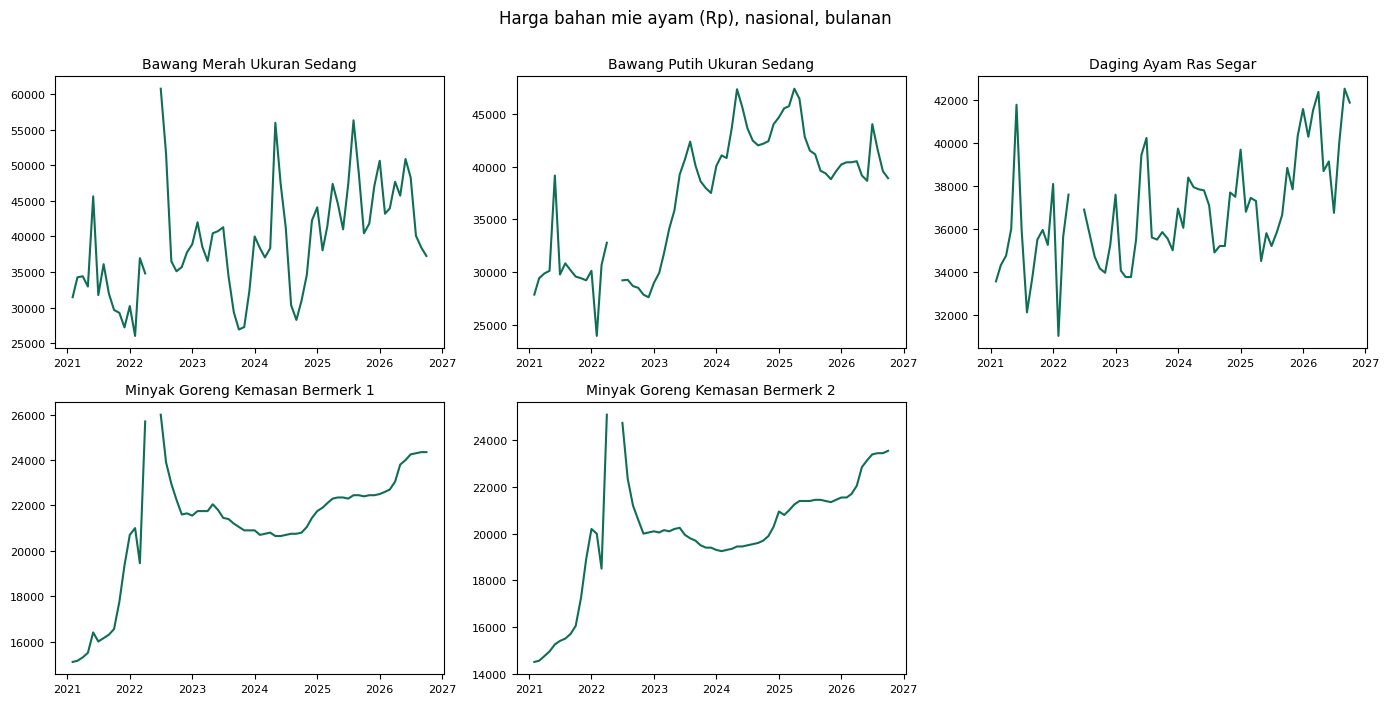

In [4]:
pivot = df.pivot(index='bulan', columns='komoditas', values='harga_rp')
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), pivot.columns):
    ax.plot(pivot.index, pivot[col], color='#0F6E56')
    ax.set_title(col, fontsize=10); ax.tick_params(labelsize=8)
axes.ravel()[-1].axis('off')
plt.suptitle('Harga bahan mie ayam (Rp), nasional, bulanan', y=1.0)
plt.tight_layout(); plt.show()

## Kesimpulan kecil

- Kita punya **5 bahan x 70 bulan** harga resmi dari PIHPS.
- Ada beberapa bulan kosong; ditangani di notebook 2.
- Terigu (bahan mie) belum ada di PIHPS, jadi dicari dari sumber lain.

**Next:** notebook 2 — berapa modal bahan semangkuk mie ayam, dan bagaimana berubah dari 2021 sampai sekarang?